### Prof. Pedram Jahangiry - Nixtla Version

This notebook demonstrates time series forecasting using **Nixtla's NeuralForecast** library with the **MLP model**.

![logo](https://upload.wikimedia.org/wikipedia/commons/4/44/Huntsman-Wordmark-with-USU-Blue.gif#center)

## 🔗 Links

[![linkedin](https://img.shields.io/badge/LinkedIn-0A66C2?style=for-the-badge&logo=linkedin&logoColor=white)](https://www.linkedin.com/in/pedram-jahangiry-cfa-5778015a)

[![Youtube](https://img.shields.io/badge/youtube_channel-1DA1F2?style=for-the-badge&logo=youtube&logoColor=white&color=FF0000)](https://www.youtube.com/channel/UCNDElcuuyX-2pSatVBDpJJQ)

[![Twitter URL](https://img.shields.io/twitter/url/https/twitter.com/PedramJahangiry.svg?style=social&label=Follow%20%40PedramJahangiry)](https://twitter.com/PedramJahangiry)

---

# Module 6 - Deep Neural Networks with Nixtla NeuralForecast

# Installation

You need to install the `neuralforecast` package:

```bash
pip install neuralforecast
```

For more information, visit: https://nixtlaverse.nixtla.io/neuralforecast/

In [3]:
# Install neuralforecast if not already installed
# !pip install neuralforecast

# check the version of neuralforecast
import neuralforecast
print(neuralforecast.__version__)  # should be 1.5.0 or higher

3.1.7


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from neuralforecast import NeuralForecast
from neuralforecast.models import MLP
from neuralforecast.losses.pytorch import  MSE

## Load and Prepare Data

NeuralForecast requires data in a specific format with columns:
- `unique_id`: Identifier for each time series
- `ds`: Timestamp
- `y`: Target variable

In [5]:
# Load data
data = pd.read_csv("https://raw.githubusercontent.com/PJalgotrader/Deep_forecasting-USU/main/data/airline_passengers.csv")
data.columns = ['ds', 'y']
data['ds'] = pd.to_datetime(data['ds'])
data['unique_id'] = 'airline'  # Add unique_id column required by NeuralForecast

# Reorder columns to match NeuralForecast format
data = data[['unique_id', 'ds', 'y']]
data.head()

,unique_id,ds,y
0,airline,1949-01-01,112
1,airline,1949-02-01,118
2,airline,1949-03-01,132
3,airline,1949-04-01,129
4,airline,1949-05-01,121


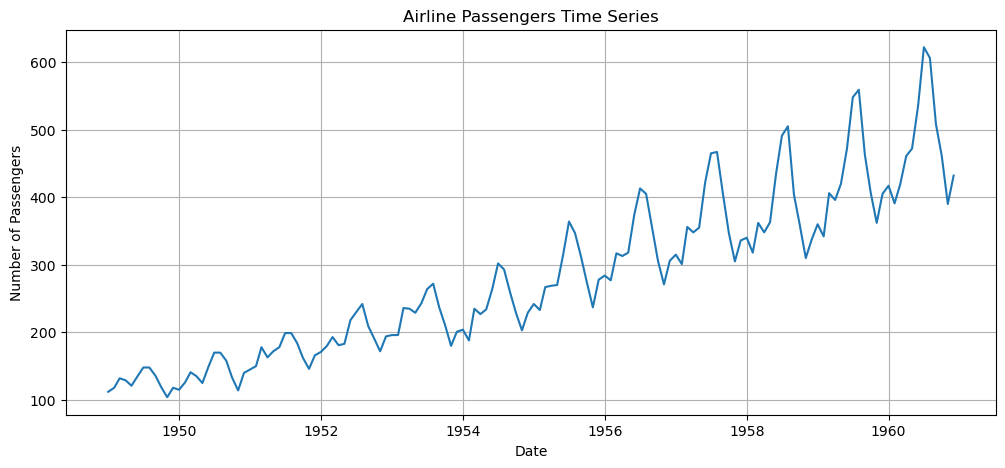

In [6]:
# Visualize the full dataset
plt.figure(figsize=(12, 5))
plt.plot(data['ds'], data['y'])
plt.title('Airline Passengers Time Series')
plt.xlabel('Date')
plt.ylabel('Number of Passengers')
plt.grid(True)
plt.show()

## Train-Test Split

Train period: 120
Test period: 24


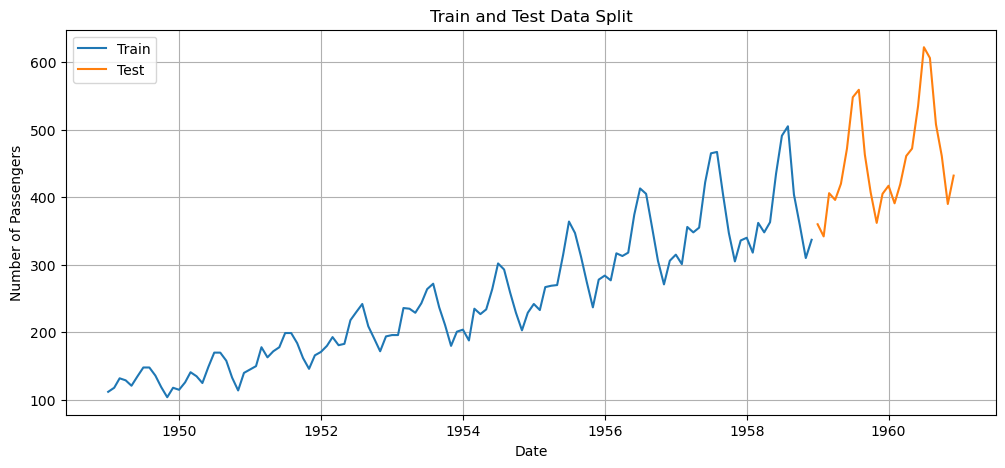

In [7]:
# Define test period
test_period = 24
train_period = len(data) - test_period

print(f"Train period: {train_period}")
print(f"Test period: {test_period}")

# Split data
train = data.iloc[:train_period]
test = data.iloc[train_period:]

# Visualize train and test split
plt.figure(figsize=(12, 5))
plt.plot(train['ds'], train['y'], label='Train')
plt.plot(test['ds'], test['y'], label='Test')
plt.title('Train and Test Data Split')
plt.xlabel('Date')
plt.ylabel('Number of Passengers')
plt.legend()
plt.grid(True)
plt.show()

## MLP Model Configuration

We'll use NeuralForecast's MLP (Multi-Layer Perceptron) model. The MLP model is a simple feedforward neural network similar to the DNN in the original notebook.

Key parameters:
- `h`: Forecast horizon (number of steps to predict)
- `input_size`: Number of lagged observations to use as input (similar to Tx)
- `num_layers`: Number of hidden layers
- `hidden_size`: Size of hidden layers
- `max_steps`: Maximum number of training steps (epochs)
- `scaler_type`: Type of scaling to apply to the data

In [8]:
# Model parameters
horizon = 1  # For one-step ahead forecasting
input_size = 12  # Number of lags (similar to Tx in original notebook)

# Initialize MLP model
models = [
    MLP(
        h=horizon,
        input_size=input_size,
        num_layers=2,
        hidden_size=32,
        loss=MSE(),
        max_steps=100,
        scaler_type='standard',
        #early_stop_patience_steps=5,
        batch_size=16,
        random_seed=42
    )
]

Seed set to 42


## Train the Model

In [9]:
# Initialize NeuralForecast
nf = NeuralForecast(models=models, freq='MS')  # MS = Month Start frequency

# Fit the model on training data
# NeuralForecast will automatically use the last 'input_size' values for validation
nf.fit(df=train)
print("Model training complete!")

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name         | Type          | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | loss         | MSE           | 0      | train | 0    
1 | padder_train | ConstantPad1d | 0      | train | 0    
2 | scaler       | TemporalNorm  | 0      | train | 0    
3 | mlp          | ModuleList    | 1.5 K  | train | 0    
4 | out          | Linear        | 33     | train | 0    
---------------------------------------------------------------
1.5 K     Trainable params
0         Non-trainable params
1.5 K     Total params
0.006     Total estimated model params size (MB)
7         Modules in train mode
0         Modules in eval mode
0         Total Flops

Epoch 99: 100%|██████████| 1/1 [00:00<00:00, 40.50it/s, v_num=0, train_loss_step=0.162, train_loss_epoch=0.162] 

`Trainer.fit` stopped: `max_steps=100` reached.


Epoch 99: 100%|██████████| 1/1 [00:00<00:00, 36.61it/s, v_num=0, train_loss_step=0.162, train_loss_epoch=0.162]
Model training complete!


## One-Step Ahead Forecasting

For one-step ahead forecasting, we predict one step at a time using actual historical values.

In [10]:
# Make predictions on the test set (one-step ahead)
# We'll use cross-validation style prediction to get one-step forecasts
test_predictions = []

for i in range(len(test)):
    # Use all data up to current point
    current_train = data.iloc[:train_period + i]

    # Predict next step
    forecast = nf.predict(df=current_train)
    test_predictions.append(forecast['MLP'].values[0])

# Add predictions to dataframe
data['MLP_1step_forecast'] = np.nan
data.loc[train_period:, 'MLP_1step_forecast'] = test_predictions

print("One-step ahead forecasting complete!")

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 174.36it/s]
One-step ahead forecasting complete!


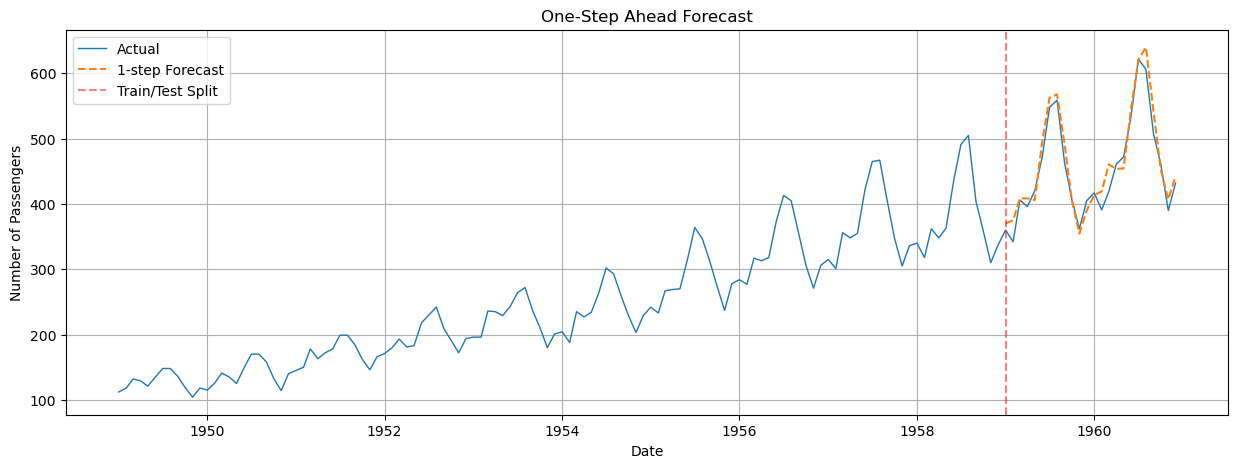

In [11]:
# Visualize one-step ahead forecast
plt.figure(figsize=(15, 5))
plt.plot(data['ds'], data['y'], label='Actual', linewidth=1)
plt.plot(data.iloc[train_period:]['ds'], data.iloc[train_period:]['MLP_1step_forecast'],
         label='1-step Forecast', linestyle='--')
plt.axvline(x=data.iloc[train_period]['ds'], color='red', linestyle='--', alpha=0.5, label='Train/Test Split')
plt.title('One-Step Ahead Forecast')
plt.xlabel('Date')
plt.ylabel('Number of Passengers')
plt.legend()
plt.grid(True)
plt.show()

## Multi-Step Forecasting

For multi-step forecasting, we predict iteratively, using previous predictions as inputs.

In [12]:
# Re-train model on full training data
nf_multistep = NeuralForecast(models=models, freq='MS')
nf_multistep.fit(df=train)

# Multi-step forecast: predict iteratively
multistep_predictions = []
current_data = train.copy()

for i in range(test_period):
    # Predict next step
    forecast = nf_multistep.predict(df=current_data)
    next_pred = forecast['MLP'].values[0]
    multistep_predictions.append(next_pred)

    # Add prediction to data for next iteration
    next_row = pd.DataFrame({
        'unique_id': ['airline'],
        'ds': [current_data['ds'].iloc[-1] + pd.DateOffset(months=1)],
        'y': [next_pred]
    })
    current_data = pd.concat([current_data, next_row], ignore_index=True)

# Add multi-step predictions to dataframe
data['MLP_multistep_forecast'] = np.nan
data.loc[train_period:, 'MLP_multistep_forecast'] = multistep_predictions

print("Multi-step forecasting complete!")

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name         | Type          | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | loss         | MSE           | 0      | train | 0    
1 | padder_train | ConstantPad1d | 0      | train | 0    
2 | scaler       | TemporalNorm  | 0      | train | 0    
3 | mlp          | ModuleList    | 1.5 K  | train | 0    
4 | out          | Linear        | 33     | train | 0    
---------------------------------------------------------------
1.5 K     Trainable params
0         Non-trainable params
1.5 K     Total params
0.006     Total estimated model params size (MB)
7         Modules in train mode
0         Modules in eval mode
0         Total Flops

Epoch 99: 100%|██████████| 1/1 [00:00<00:00, 36.40it/s, v_num=2, train_loss_step=0.162, train_loss_epoch=0.162] 

`Trainer.fit` stopped: `max_steps=100` reached.


Epoch 99: 100%|██████████| 1/1 [00:00<00:00, 33.72it/s, v_num=2, train_loss_step=0.162, train_loss_epoch=0.162]


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 138.33it/s]
Multi-step forecasting complete!


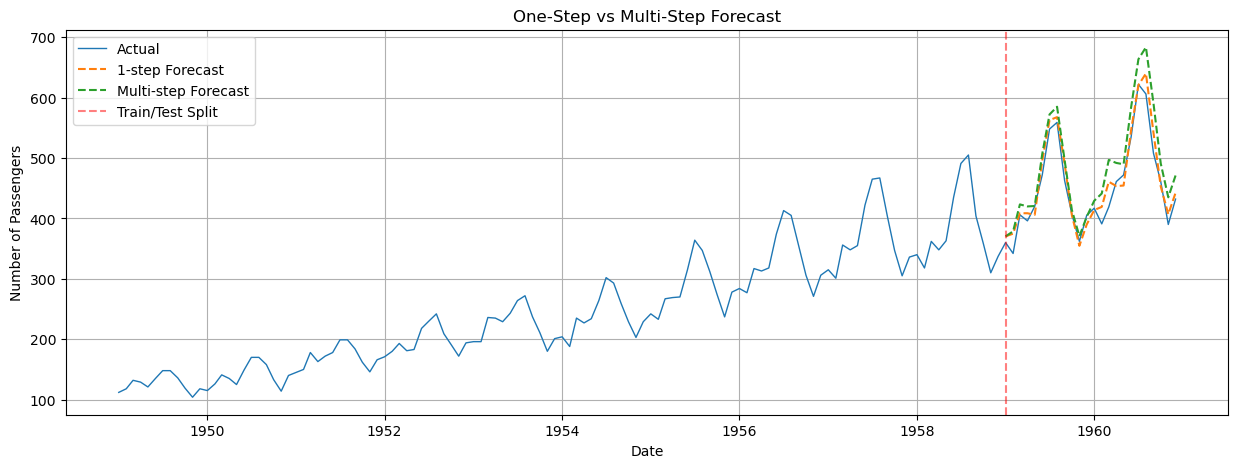

In [13]:
# Visualize one-step and multi-step forecasts
plt.figure(figsize=(15, 5))
plt.plot(data['ds'], data['y'], label='Actual', linewidth=1)
plt.plot(data.iloc[train_period:]['ds'], data.iloc[train_period:]['MLP_1step_forecast'],
         label='1-step Forecast', linestyle='--')
plt.plot(data.iloc[train_period:]['ds'], data.iloc[train_period:]['MLP_multistep_forecast'],
         label='Multi-step Forecast', linestyle='--')
plt.axvline(x=data.iloc[train_period]['ds'], color='red', linestyle='--', alpha=0.5, label='Train/Test Split')
plt.title('One-Step vs Multi-Step Forecast')
plt.xlabel('Date')
plt.ylabel('Number of Passengers')
plt.legend()
plt.grid(True)
plt.show()

## Multi-Output Forecasting

For multi-output forecasting, we configure the model to predict all future values at once by setting `h=test_period`.

In [14]:
# Initialize MLP model for multi-output forecasting
horizon_multi = test_period  # Predict all test periods at once

models_multi = [
    MLP(
        h=horizon_multi,
        input_size=input_size,
        num_layers=2,
        hidden_size=32,
        loss=MSE(),
        max_steps=200,
        scaler_type='standard',
        batch_size=16,
        random_seed=42
    )
]

# Train model for multi-output
nf_multi = NeuralForecast(models=models_multi, freq='MS')
nf_multi.fit(df=train)

# Make multi-output prediction
forecast_multi = nf_multi.predict(df=train)

# Add multi-output predictions to dataframe
data['MLP_multioutput_forecast'] = np.nan
data.loc[train_period:, 'MLP_multioutput_forecast'] = forecast_multi['MLP'].values

print("Multi-output forecasting complete!")

Seed set to 42
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name         | Type          | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | loss         | MSE           | 0      | train | 0    
1 | padder_train | ConstantPad1d | 0      | train | 0    
2 | scaler       | TemporalNorm  | 0      | train | 0    
3 | mlp          | ModuleList    | 1.5 K  | train | 0    
4 | out          | Linear        | 792    | train | 0    
---------------------------------------------------------------
2.3 K     Trainable params
0         Non-trainable params
2.3 K     Total params
0.009     Total estimated model params size (MB)
7         Modules in train mode
0         Modules in eval mode
0     

Epoch 199: 100%|██████████| 1/1 [00:00<00:00, 36.98it/s, v_num=4, train_loss_step=0.622, train_loss_epoch=0.622] 

`Trainer.fit` stopped: `max_steps=200` reached.


Epoch 199: 100%|██████████| 1/1 [00:00<00:00, 33.28it/s, v_num=4, train_loss_step=0.622, train_loss_epoch=0.622]


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 28.98it/s]
Multi-output forecasting complete!


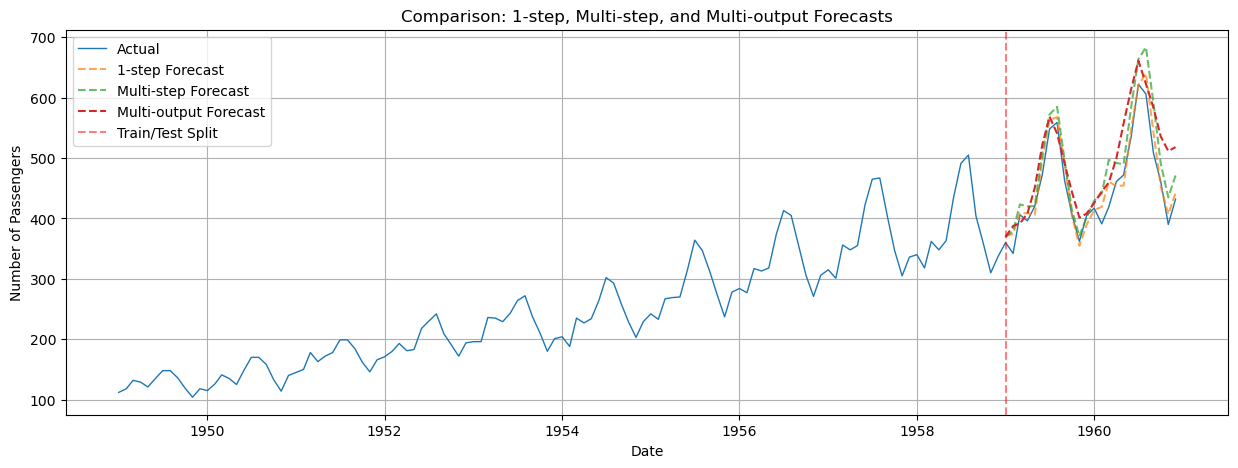

In [15]:
# Visualize all three forecast types
plt.figure(figsize=(15, 5))
plt.plot(data['ds'], data['y'], label='Actual', linewidth=1)
plt.plot(data.iloc[train_period:]['ds'], data.iloc[train_period:]['MLP_1step_forecast'],
         label='1-step Forecast', linestyle='--', alpha=0.7)
plt.plot(data.iloc[train_period:]['ds'], data.iloc[train_period:]['MLP_multistep_forecast'],
         label='Multi-step Forecast', linestyle='--', alpha=0.7)
plt.plot(data.iloc[train_period:]['ds'], data.iloc[train_period:]['MLP_multioutput_forecast'],
         label='Multi-output Forecast', linestyle='--')
plt.axvline(x=data.iloc[train_period]['ds'], color='red', linestyle='--', alpha=0.5, label='Train/Test Split')
plt.title('Comparison: 1-step, Multi-step, and Multi-output Forecasts')
plt.xlabel('Date')
plt.ylabel('Number of Passengers')
plt.legend()
plt.grid(True)
plt.show()

## Forecast Comparison using MAPE

In [16]:
# Define MAPE function
def mean_absolute_percentage_error(y_true, y_pred):
    """
    Calculate Mean Absolute Percentage Error (MAPE)
    """
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [17]:
# Calculate MAPE for each forecast type
actual_test = data.loc[train_period:, 'y'].values

mape_1step = mean_absolute_percentage_error(actual_test, data.loc[train_period:, 'MLP_1step_forecast'])
mape_multistep = mean_absolute_percentage_error(actual_test, data.loc[train_period:, 'MLP_multistep_forecast'])
mape_multioutput = mean_absolute_percentage_error(actual_test, data.loc[train_period:, 'MLP_multioutput_forecast'])

print("=" * 50)
print("MAPE Comparison")
print("=" * 50)
print(f"1-step forecast MAPE:      {mape_1step:.4f}%")
print(f"Multi-step forecast MAPE:  {mape_multistep:.4f}%")
print(f"Multi-output forecast MAPE: {mape_multioutput:.4f}%")
print("=" * 50)

MAPE Comparison
1-step forecast MAPE:      3.6426%
Multi-step forecast MAPE:  7.0528%
Multi-output forecast MAPE: 9.6496%


In [18]:
# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Forecast Type': ['1-step', 'Multi-step', 'Multi-output'],
    'MAPE': [mape_1step, mape_multistep, mape_multioutput]
})

comparison_df

,Forecast Type,MAPE
0,1-step,3.642582
1,Multi-step,7.052755
2,Multi-output,9.649595


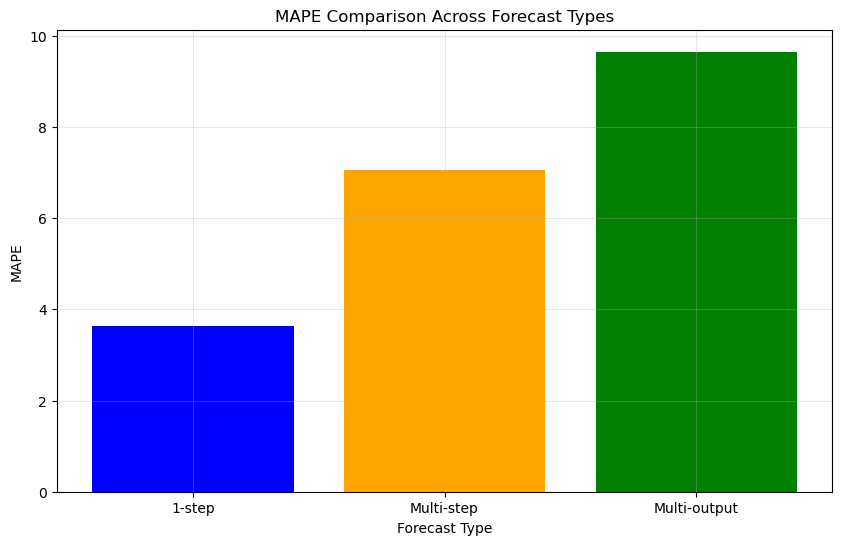

In [19]:
# Visualize MAPE comparison
plt.figure(figsize=(10, 6))
plt.bar(comparison_df['Forecast Type'], comparison_df['MAPE'], color=['blue', 'orange', 'green'])
plt.title('MAPE Comparison Across Forecast Types')
plt.ylabel('MAPE')
plt.xlabel('Forecast Type')
plt.grid(True, alpha=0.3)
plt.show()

## NeuralForecast MLP Forecaster Function

Similar to the `dl_ts_forecaster` function in the original notebook, here's a wrapper function for easy forecasting with NeuralForecast MLP.

In [20]:
def mlp_ts_forecaster(data, target='y', lags=12, fh=12, unique_id='series1', freq='MS',
                      max_steps=100, hidden_size=32, num_layers=2):
    """
    Time series forecasting using Nixtla's NeuralForecast MLP model.

    Parameters:
    -----------
    data : pd.DataFrame
        Input dataframe with date index and target column
    target : str
        Name of target column to forecast
    lags : int
        Number of lagged observations to use as input
    fh : int
        Forecast horizon (number of steps ahead)
    unique_id : str
        Identifier for the time series
    freq : str
        Frequency of the time series (e.g., 'MS' for month start)
    max_steps : int
        Maximum training steps
    hidden_size : int
        Size of hidden layers
    num_layers : int
        Number of hidden layers

    Returns:
    --------
    pd.DataFrame
        Original dataframe with forecast columns added
    """

    # Prepare data in NeuralForecast format
    df = data.copy()
    if 'ds' not in df.columns:
        df = df.reset_index()
        df.columns = ['ds', target]

    df['unique_id'] = unique_id
    df = df.rename(columns={target: 'y'})
    df = df[['unique_id', 'ds', 'y']]

    # Train-test split
    train_period = len(df) - fh
    train = df.iloc[:train_period]

    print(f"Training period: {train_period}, Test period: {fh}")

    # Initialize models
    models_1step = [
        MLP(h=1, input_size=lags, num_layers=num_layers, hidden_size=hidden_size,
            loss=MSE(), max_steps=max_steps, scaler_type='standard',
            batch_size=16, random_seed=42)
    ]

    models_multi = [
        MLP(h=fh, input_size=lags, num_layers=num_layers, hidden_size=hidden_size,
            loss=MSE(), max_steps=max_steps*2, scaler_type='standard',
            batch_size=16, random_seed=42)
    ]

    # 1-step ahead forecasting
    print("\nTraining 1-step ahead model...")
    nf_1step = NeuralForecast(models=models_1step, freq=freq)
    nf_1step.fit(df=train)

    predictions_1step = []
    for i in range(fh):
        current_train = df.iloc[:train_period + i]
        forecast = nf_1step.predict(df=current_train)
        predictions_1step.append(forecast['MLP'].values[0])

    # Multi-step forecasting
    print("Generating multi-step forecast...")
    multistep_predictions = []
    current_data = train.copy()

    for i in range(fh):
        forecast = nf_1step.predict(df=current_data)
        next_pred = forecast['MLP'].values[0]
        multistep_predictions.append(next_pred)

        next_row = pd.DataFrame({
            'unique_id': [unique_id],
            'ds': [current_data['ds'].iloc[-1] + pd.DateOffset(months=1)],
            'y': [next_pred]
        })
        current_data = pd.concat([current_data, next_row], ignore_index=True)

    # Multi-output forecasting
    print("Training multi-output model...")
    nf_multi = NeuralForecast(models=models_multi, freq=freq)
    nf_multi.fit(df=train)
    forecast_multi = nf_multi.predict(df=train)

    # Add predictions to dataframe
    df['MLP_1step_forecast'] = np.nan
    df['MLP_multistep_forecast'] = np.nan
    df['MLP_multioutput_forecast'] = np.nan

    df.loc[train_period:, 'MLP_1step_forecast'] = predictions_1step
    df.loc[train_period:, 'MLP_multistep_forecast'] = multistep_predictions
    df.loc[train_period:, 'MLP_multioutput_forecast'] = forecast_multi['MLP'].values

    # Calculate MAPE
    actual = df.loc[train_period:, 'y'].values
    mape_1step = mean_absolute_percentage_error(actual, df.loc[train_period:, 'MLP_1step_forecast'])
    mape_multistep = mean_absolute_percentage_error(actual, df.loc[train_period:, 'MLP_multistep_forecast'])
    mape_multioutput = mean_absolute_percentage_error(actual, df.loc[train_period:, 'MLP_multioutput_forecast'])

    print("\n" + "="*50)
    print("MAPE Results")
    print("="*50)
    print(f"1-step MAPE:      {mape_1step:.4f}%")
    print(f"Multi-step MAPE:  {mape_multistep:.4f}%")
    print(f"Multi-output MAPE: {mape_multioutput:.4f}%")
    print("="*50)

    # Plot
    plt.figure(figsize=(15, 5))
    plt.plot(df['ds'], df['y'], label='Actual', linewidth=1)
    plt.plot(df.iloc[train_period:]['ds'], df.iloc[train_period:]['MLP_1step_forecast'],
             label='1-step Forecast', linestyle='--', alpha=0.7)
    plt.plot(df.iloc[train_period:]['ds'], df.iloc[train_period:]['MLP_multistep_forecast'],
             label='Multi-step Forecast', linestyle='--', alpha=0.7)
    plt.plot(df.iloc[train_period:]['ds'], df.iloc[train_period:]['MLP_multioutput_forecast'],
             label='Multi-output Forecast', linestyle='--',  alpha=0.7)
    plt.axvline(x=df.iloc[train_period]['ds'], color='red', linestyle='--', alpha=0.5, label='Train/Test Split')
    plt.title('MLP Forecasts Comparison')
    plt.xlabel('Date')
    plt.ylabel(target)
    plt.legend()
    plt.grid(True)
    plt.show()

    return df

## Test the Forecaster Function

Seed set to 42
Seed set to 42
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name         | Type          | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | loss         | MSE           | 0      | train | 0    
1 | padder_train | ConstantPad1d | 0      | train | 0    
2 | scaler       | TemporalNorm  | 0      | train | 0    
3 | mlp          | ModuleList    | 1.9 K  | train | 0    
4 | out          | Linear        | 33     | train | 0    
---------------------------------------------------------------
1.9 K     Trainable params
0         Non-trainable params
1.9 K     Total params
0.008     Total estimated model params size (MB)
7         Modules in train mode
0         Modules in e

Training period: 132, Test period: 12

Training 1-step ahead model...
Epoch 99: 100%|██████████| 1/1 [00:00<00:00, 63.67it/s, v_num=6, train_loss_step=0.0793, train_loss_epoch=0.0793] 

`Trainer.fit` stopped: `max_steps=100` reached.


Epoch 99: 100%|██████████| 1/1 [00:00<00:00, 56.64it/s, v_num=6, train_loss_step=0.0793, train_loss_epoch=0.0793]


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


...

Epoch 199: 100%|██████████| 1/1 [00:00<00:00, 34.62it/s, v_num=8, train_loss_step=0.257, train_loss_epoch=0.257] 

`Trainer.fit` stopped: `max_steps=200` reached.


Epoch 199: 100%|██████████| 1/1 [00:00<00:00, 30.70it/s, v_num=8, train_loss_step=0.257, train_loss_epoch=0.257]


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 146.80it/s]

MAPE Results
1-step MAPE:      3.5326%
Multi-step MAPE:  4.9576%
Multi-output MAPE: 4.6806%


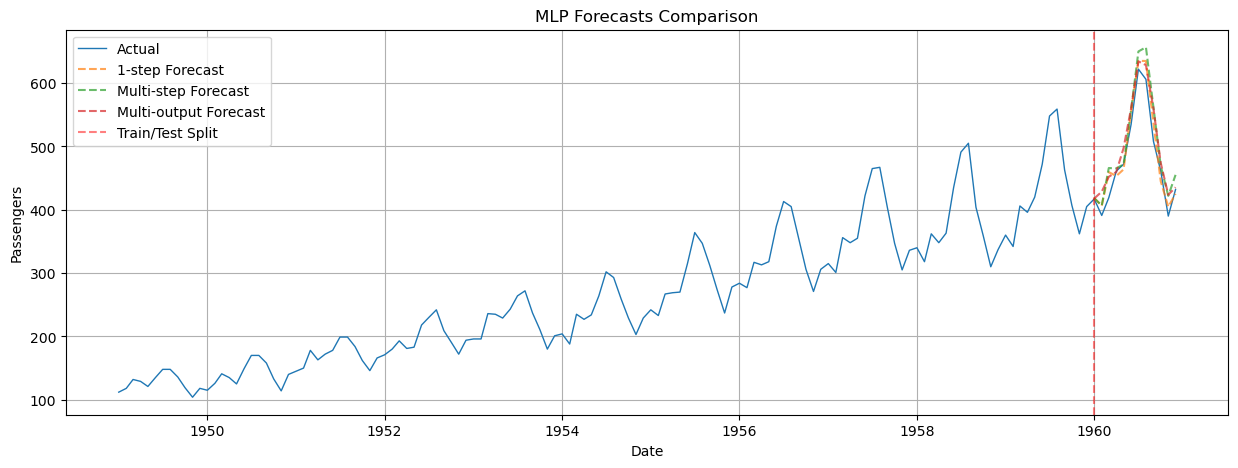

In [21]:
# Load fresh data
df_test = pd.read_csv("https://raw.githubusercontent.com/PJalgotrader/Deep_forecasting-USU/main/data/airline_passengers.csv",
                      index_col="Month", parse_dates=True)

# Run the forecaster
result = mlp_ts_forecaster(df_test, target='Passengers', lags=24, fh=12, freq='MS')

In [22]:
# View results
result.tail(15)

,unique_id,ds,y,MLP_1step_forecast,MLP_multistep_forecast,MLP_multioutput_forecast
129,series1,1959-10-01,407,NaN,NaN,NaN
130,series1,1959-11-01,362,NaN,NaN,NaN
131,series1,1959-12-01,405,NaN,NaN,NaN
132,series1,1960-01-01,417,418.451050,418.451050,417.812897
133,series1,1960-02-01,391,406.166229,406.660706,428.513306
134,series1,1960-03-01,419,459.488159,465.876648,452.013336
135,series1,1960-04-01,461,453.303101,465.248535,459.773682
136,series1,1960-05-01,472,463.768127,471.810211,497.537170
137,series1,1960-06-01,535,555.193665,557.844543,560.400879
138,series1,1960-07-01,622,635.108093,649.938354,634.313782


## Test with Log-Transformed Data

Seed set to 42
Seed set to 42


Training period: 132, Test period: 12

Training 1-step ahead model...


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name         | Type          | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | loss         | MSE           | 0      | train | 0    
1 | padder_train | ConstantPad1d | 0      | train | 0    
2 | scaler       | TemporalNorm  | 0      | train | 0    
3 | mlp          | ModuleList    | 1.5 K  | train | 0    
4 | out          | Linear        | 33     | train | 0    
---------------------------------------------------------------
1.5 K     Trainable params
0         Non-trainable params
1.5 K     Total params
0.006     Total estimated model params size (MB)
7         Modules in train mode
0         Modules in eval mode
0         Total Flops

Epoch 99: 100%|██████████| 1/1 [00:00<00:00, 39.42it/s, v_num=10, train_loss_step=0.144, train_loss_epoch=0.144] 

`Trainer.fit` stopped: `max_steps=100` reached.


...

Epoch 199: 100%|██████████| 1/1 [00:00<00:00, 45.16it/s, v_num=12, train_loss_step=0.267, train_loss_epoch=0.267] 

`Trainer.fit` stopped: `max_steps=200` reached.


Epoch 199: 100%|██████████| 1/1 [00:00<00:00, 39.96it/s, v_num=12, train_loss_step=0.267, train_loss_epoch=0.267]


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 38.43it/s]

MAPE Results
1-step MAPE:      0.5632%
Multi-step MAPE:  0.5880%
Multi-output MAPE: 0.7847%


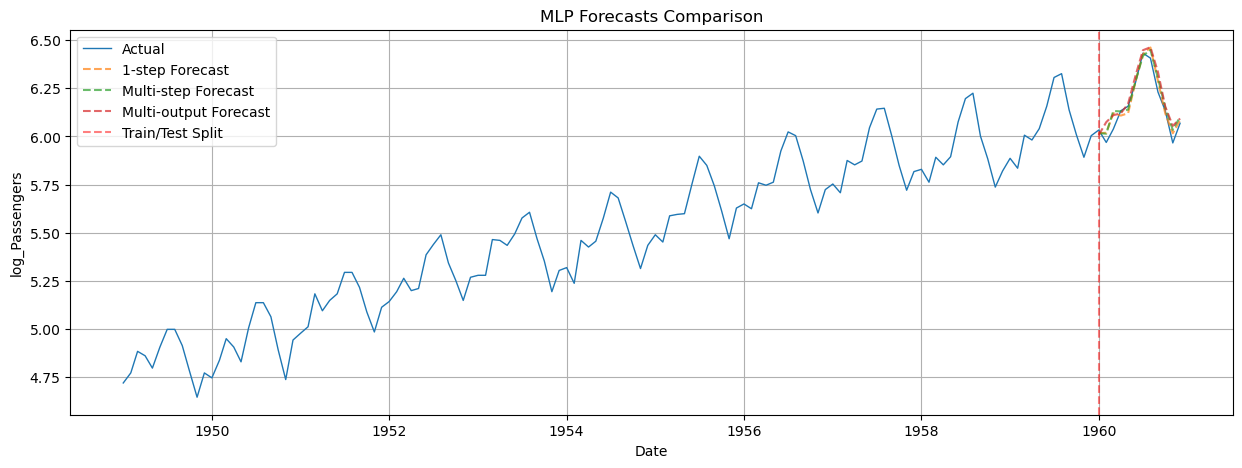

In [23]:
# Load data and apply log transformation
df_log = pd.read_csv("https://raw.githubusercontent.com/PJalgotrader/Deep_forecasting-USU/main/data/airline_passengers.csv",
                     index_col="Month", parse_dates=True)
df_log['log_Passengers'] = np.log(df_log['Passengers'])

# Select only the log-transformed column for forecasting
df_log_forecast = df_log[['log_Passengers']].copy()

# Run forecaster on log-transformed data
result_log = mlp_ts_forecaster(df_log_forecast, target='log_Passengers', lags=12, fh=12, freq='MS')

In [24]:
# View results
result_log.tail(15)

,unique_id,ds,y,MLP_1step_forecast,MLP_multistep_forecast,MLP_multioutput_forecast
129,series1,1959-10-01,6.008813,NaN,NaN,NaN
130,series1,1959-11-01,5.891644,NaN,NaN,NaN
131,series1,1959-12-01,6.003887,NaN,NaN,NaN
132,series1,1960-01-01,6.033086,6.016983,6.016983,6.007383
133,series1,1960-02-01,5.968708,6.018805,6.014024,6.074298
134,series1,1960-03-01,6.037871,6.120376,6.131947,6.110192
135,series1,1960-04-01,6.133398,6.108290,6.130157,6.119928
136,series1,1960-05-01,6.156979,6.120509,6.139349,6.169795
137,series1,1960-06-01,6.282267,6.287576,6.290723,6.318142
138,series1,1960-07-01,6.432940,6.427065,6.419058,6.448049


# Summary

This notebook demonstrates time series forecasting using **Nixtla's NeuralForecast MLP model**, which is a modern alternative to traditional deep learning frameworks like TensorFlow/Keras.

## Key Differences from Original Notebook:

1. **Data Format**: NeuralForecast requires data in long format with columns `unique_id`, `ds`, and `y`
2. **Model API**: Uses Nixtla's simplified API instead of Keras functional API
3. **Built-in Features**: NeuralForecast provides built-in scaling, early stopping, and validation
4. **Time Series Focus**: Designed specifically for time series forecasting

## Three Forecasting Approaches:

1. **1-step ahead**: Uses actual values for each prediction (best accuracy)
2. **Multi-step**: Iterative prediction using previous forecasts
3. **Multi-output**: Predicts all future values at once (model configured with `h=fh`)

## Resources:
- NeuralForecast Documentation: https://nixtlaverse.nixtla.io/neuralforecast/
- MLP Model: https://nixtlaverse.nixtla.io/neuralforecast/models.mlp.html

# Done!

# Bonus: Simple AutoMLP Example

Let's create a simple AutoMLP model that automatically searches for the best hyperparameters.

In [25]:
import neuralforecast.auto as auto_module

# Get all attributes that start with 'Auto'
auto_models = [attr for attr in dir(auto_module) if attr.startswith('Auto')]

print("Available Auto Models:")
for model in sorted(auto_models):
    print(f"  - {model}")

Available Auto Models:
  - AutoAutoformer
  - AutoBiTCN
  - AutoDLinear
  - AutoDeepAR
  - AutoDeepNPTS
  - AutoDilatedRNN
  - AutoFEDformer
  - AutoGRU
  - AutoHINT
  - AutoInformer
  - AutoKAN
  - AutoLSTM
  - AutoMLP
  - AutoMLPMultivariate
  - AutoNBEATS
  - AutoNBEATSx
  - AutoNHITS
  - AutoNLinear
  - AutoPatchTST
  - AutoRMoK
  - AutoRNN
  - AutoSOFTS
  - AutoStemGNN
  - AutoTCN
  - AutoTFT
  - AutoTSMixer
  - AutoTSMixerx
  - AutoTiDE
  - AutoTimeMixer
  - AutoTimeXer
  - AutoTimesNet
  - AutoVanillaTransformer
  - AutoXLinear
  - Autoformer
  - AutoiTransformer
  - AutoxLSTM


In [26]:
# import automlp
from neuralforecast.auto import AutoMLP
# Create a simple AutoMLP model with default configuration
# This will automatically search for good hyperparameters
model_auto = AutoMLP(
    h=test_period,  # Forecast horizon (24 months)
    num_samples=3,  # Try 3 different configurations (keep it simple)
    cpus=1,
)

print("AutoMLP model created!")
print(f"Will test {model_auto.num_samples} different configurations")

AutoMLP model created!
Will test 3 different configurations


In [27]:
# Train AutoMLP (this may take a few minutes as it tests multiple configurations)
print("Training AutoMLP...\n")

nf_auto = NeuralForecast(models=[model_auto], freq='MS')
# Provide validation size for hyperparameter tuning
nf_auto.fit(df=train, val_size=0)

print("\nAutoMLP training complete!")

(_train_tune pid=94371) /opt/anaconda3/envs/nixtla/lib/python3.11/site-packages/ray/tune/integration/pytorch_lightning.py:198: `ray.tune.integration.pytorch_lightning.TuneReportCallback` is deprecated. Use `ray.tune.integration.pytorch_lightning.TuneReportCheckpointCallback` instead.
(_train_tune pid=94371) Seed set to 3
(_train_tune pid=94371) GPU available: True (mps), used: True
(_train_tune pid=94371) TPU available: False, using: 0 TPU cores
(_train_tune pid=94371) 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
(_train_tune pid=94371) 
(_train_tune pid=94371)   | Name         | Type          | Params | Mode  | FLOPs
(_train_tune pid=94371) ---------------------------------------------------------------
(_train_tune pid=94371) 0 | loss         | MAE           | 0      | train | 0    
(_train_tune pid=94

Sanity Checking: |          | 0/? [00:00<?, ?it/s]
Epoch 0:   0%|          | 0/1 [00:00<?, ?it/s]                             


2026-04-15 10:23:37,479	ERROR tune_controller.py:1326 -- Trial task failed for trial _train_tune_6c848_00001
Traceback (most recent call last):
  File "/opt/anaconda3/envs/nixtla/lib/python3.11/site-packages/ray/air/execution/_internal/event_manager.py", line 110, in resolve_future
    result = ray.get(future)
             ^^^^^^^^^^^^^^^
  File "/opt/anaconda3/envs/nixtla/lib/python3.11/site-packages/ray/_private/auto_init_hook.py", line 22, in auto_init_wrapper
    return fn(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/envs/nixtla/lib/python3.11/site-packages/ray/_private/client_mode_hook.py", line 107, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/envs/nixtla/lib/python3.11/site-packages/ray/_private/worker.py", line 2980, in get
    values, debugger_breakpoint = worker.get_objects(
                                  ^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/envs/nixtla/lib/python3.11/site-packages/ray/_

Epoch 43:   0%|          | 0/1 [00:00<?, ?it/s, v_num=0, train_loss_step=36.90, train_loss_epoch=36.90]         
Sanity Checking: |          | 0/? [00:00<?, ?it/s] [repeated 2x across cluster] (Ray deduplicates logs by default. Set RAY_DEDUP_LOGS=0 to disable log deduplication, or see https://docs.ray.io/en/master/ray-observability/user-guides/configure-logging.html#log-deduplication for more options.)
Epoch 99: 100%|██████████| 1/1 [00:00<00:00, 73.27it/s, v_num=0, train_loss_step=37.20, train_loss_epoch=37.00]
(_train_tune pid=94369) 
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 199: 100%|██████████| 1/1 [00:00<00:00, 62.55it/s, v_num=0, train_loss_step=37.10, train_loss_epoch=37.00, valid_loss=22.10]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 388:   0%|          | 0/1 [00:00<?, ?it/s, v_num=0, train_loss_step=37.20, train_loss_epoch=37.20, valid_loss=22.00]         
Validation

(_train_tune pid=94369) `Trainer.fit` stopped: `max_steps=500` reached.
(_train_tune pid=94370) /opt/anaconda3/envs/nixtla/lib/python3.11/site-packages/ray/tune/integration/pytorch_lightning.py:198: `ray.tune.integration.pytorch_lightning.TuneReportCallback` is deprecated. Use `ray.tune.integration.pytorch_lightning.TuneReportCheckpointCallback` instead. [repeated 2x across cluster]
(_train_tune pid=94370) Seed set to 1 [repeated 2x across cluster]
(_train_tune pid=94370) GPU available: True (mps), used: True [repeated 2x across cluster]
(_train_tune pid=94370) TPU available: False, using: 0 TPU cores [repeated 2x across cluster]
(_train_tune pid=94370) 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform. [repeated 2x across cluster]
(_train_tune pid=94370)   | Name         | Type          | Params | Mode  | FLO

Epoch 427:   0%|          | 0/1 [00:00<?, ?it/s, v_num=0, train_loss_step=0.104, train_loss_epoch=0.104, valid_loss=21.60]        
Validation: |          | 0/? [00:00<?, ?it/s] [repeated 8x across cluster]
Epoch 499: 100%|██████████| 1/1 [00:00<00:00, 44.37it/s, v_num=0, train_loss_step=0.153, train_loss_epoch=0.198, valid_loss=21.60]  
(_train_tune pid=94371) 
Epoch 599: 100%|██████████| 1/1 [00:00<00:00, 43.54it/s, v_num=0, train_loss_step=0.111, train_loss_epoch=0.111, valid_loss=23.00]  
(_train_tune pid=94371) 
Epoch 644:   0%|          | 0/1 [00:00<?, ?it/s, v_num=0, train_loss_step=0.146, train_loss_epoch=0.146, valid_loss=26.40]          
Validation: |          | 0/? [00:00<?, ?it/s] [repeated 4x across cluster]
Epoch 766: 100%|██████████| 1/1 [00:00<00:00, 46.15it/s, v_num=0, train_loss_step=0.0706, train_loss_epoch=0.0706, valid_loss=23.20] [repeated 6x across cluster]
(_train_tune pid=94371) 
(_train_tune pid=94371) 
(_train_tune pid=94371) 
Epoch 857:   0%|          | 0/1 [

2026-04-15 10:24:05,006	INFO tune.py:1001 -- Wrote the latest version of all result files and experiment state to '/Users/a02291312/ray_results/_train_tune_2026-04-15_10-23-23' in 0.0051s.
2026-04-15 10:24:05,008	ERROR tune.py:1029 -- Trials did not complete: [_train_tune_6c848_00001]
(_train_tune pid=94371) `Trainer.fit` stopped: `max_steps=1000` reached.
Seed set to 5
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name         | Type          | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | loss         | MAE           | 0      | eval  | 0    
1 | padder_train | ConstantPad1d | 0      | train | 0    
2 | scaler       | TemporalNorm  | 0      | train | 0    
3 | mlp          | Mo

Epoch 499: 100%|██████████| 1/1 [00:00<00:00, 49.09it/s, v_num=14, train_loss_step=52.70, train_loss_epoch=52.70]  

`Trainer.fit` stopped: `max_steps=500` reached.


Epoch 499: 100%|██████████| 1/1 [00:00<00:00, 44.99it/s, v_num=14, train_loss_step=52.70, train_loss_epoch=52.70]

AutoMLP training complete!


In [28]:
# Make predictions with AutoMLP
forecast_auto = nf_auto.predict(df=train)

# Add AutoMLP predictions to dataframe
data['AutoMLP_forecast'] = np.nan
data.loc[train_period:, 'AutoMLP_forecast'] = forecast_auto['AutoMLP'].values

# Calculate MAPE for AutoMLP
mape_auto = mean_absolute_percentage_error(actual_test, data.loc[train_period:, 'AutoMLP_forecast'])

print("=" * 50)
print("AutoMLP Performance")
print("=" * 50)
print(f"AutoMLP forecast MAPE: {mape_auto:.4f}%")
print("=" * 50)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00,  7.76it/s]
AutoMLP Performance
AutoMLP forecast MAPE: 17.1189%


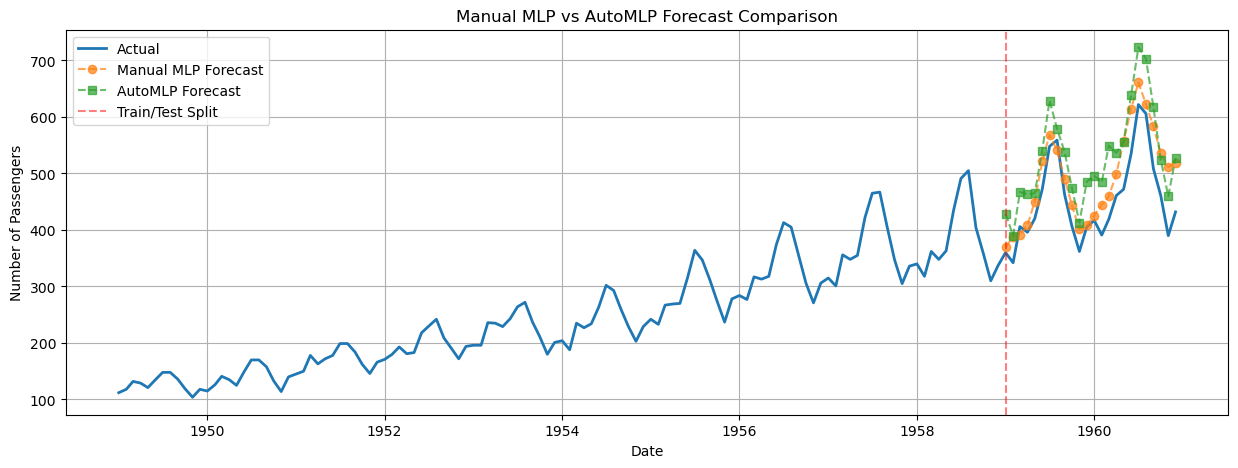

In [29]:
# Visualize AutoMLP forecast compared to manual MLP
plt.figure(figsize=(15, 5))
plt.plot(data['ds'], data['y'], label='Actual', linewidth=2)
plt.plot(data.iloc[train_period:]['ds'], data.iloc[train_period:]['MLP_multioutput_forecast'],
         label='Manual MLP Forecast', linestyle='--', marker='o', alpha=0.7)
plt.plot(data.iloc[train_period:]['ds'], data.iloc[train_period:]['AutoMLP_forecast'],
         label='AutoMLP Forecast', linestyle='--', marker='s', alpha=0.7)
plt.axvline(x=data.iloc[train_period]['ds'], color='red', linestyle='--', alpha=0.5, label='Train/Test Split')
plt.title('Manual MLP vs AutoMLP Forecast Comparison')
plt.xlabel('Date')
plt.ylabel('Number of Passengers')
plt.legend()
plt.grid(True)
plt.show()

Final MAPE Comparison - All Models
                    Model  MAPE (%)
                   1-step  3.642582
               Multi-step  7.052755
Multi-output (Manual MLP)  9.649595
                  AutoMLP 17.118948


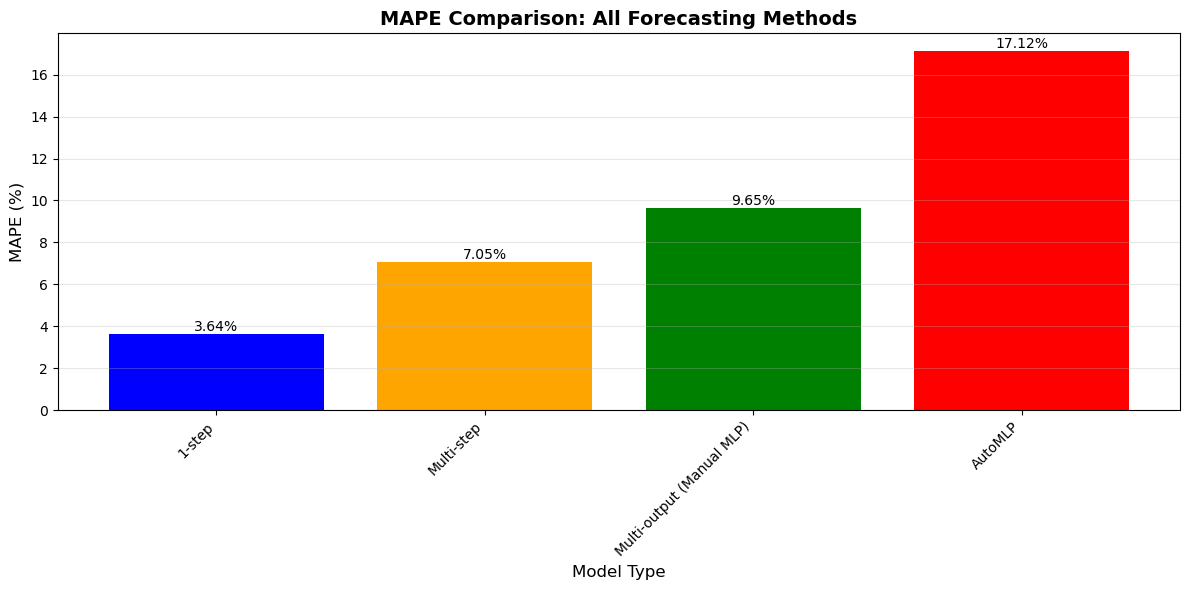

,Model,MAPE (%)
0,1-step,3.642582
1,Multi-step,7.052755
2,Multi-output (Manual MLP),9.649595
3,AutoMLP,17.118948


In [30]:
# Final comparison: All models
comparison_all = pd.DataFrame({
    'Model': ['1-step', 'Multi-step', 'Multi-output (Manual MLP)', 'AutoMLP'],
    'MAPE (%)': [mape_1step, mape_multistep, mape_multioutput, mape_auto]
})

comparison_all = comparison_all.sort_values('MAPE (%)')

print("=" * 60)
print("Final MAPE Comparison - All Models")
print("=" * 60)
print(comparison_all.to_string(index=False))
print("=" * 60)

# Visualize
plt.figure(figsize=(12, 6))
colors = ['blue', 'orange', 'green', 'red']
bars = plt.bar(comparison_all['Model'], comparison_all['MAPE (%)'], color=colors)
plt.title('MAPE Comparison: All Forecasting Methods', fontsize=14, fontweight='bold')
plt.ylabel('MAPE (%)', fontsize=12)
plt.xlabel('Model Type', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2f}%',
             ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

comparison_all